# Algoritmo de Grover

Ele resolve um problema genuinamente difícil — busca em banco de dados não estruturado — com speedup quadrático provado: de O(N) para O(√N).

O problema: você tem N = 2ⁿ itens, um deles é o "vencedor" (marcado pelo oráculo), e você não sabe qual. Classicamente precisa de N/2 tentativas em média. Grover encontra em ~π/4 · √N iterações.

Cada iteração rotaciona o estado quântico por um ângulo fixo 2θ em direção ao vencedor. No número ótimo de iterações (≈ π/4·√N), a amplitude do vencedor está no máximo. Se você passar do ponto ótimo, a amplitude começa a cair — o algoritmo "passa do alvo".

A geometria é a chave: Grover é literalmente uma rotação no espaço de estados. Cada iteração tem dois passos — o oráculo reflete o estado em torno do hiperplano ⊥ ao vencedor, e o difusor reflete em torno do estado médio. Duas reflexões = uma rotação.

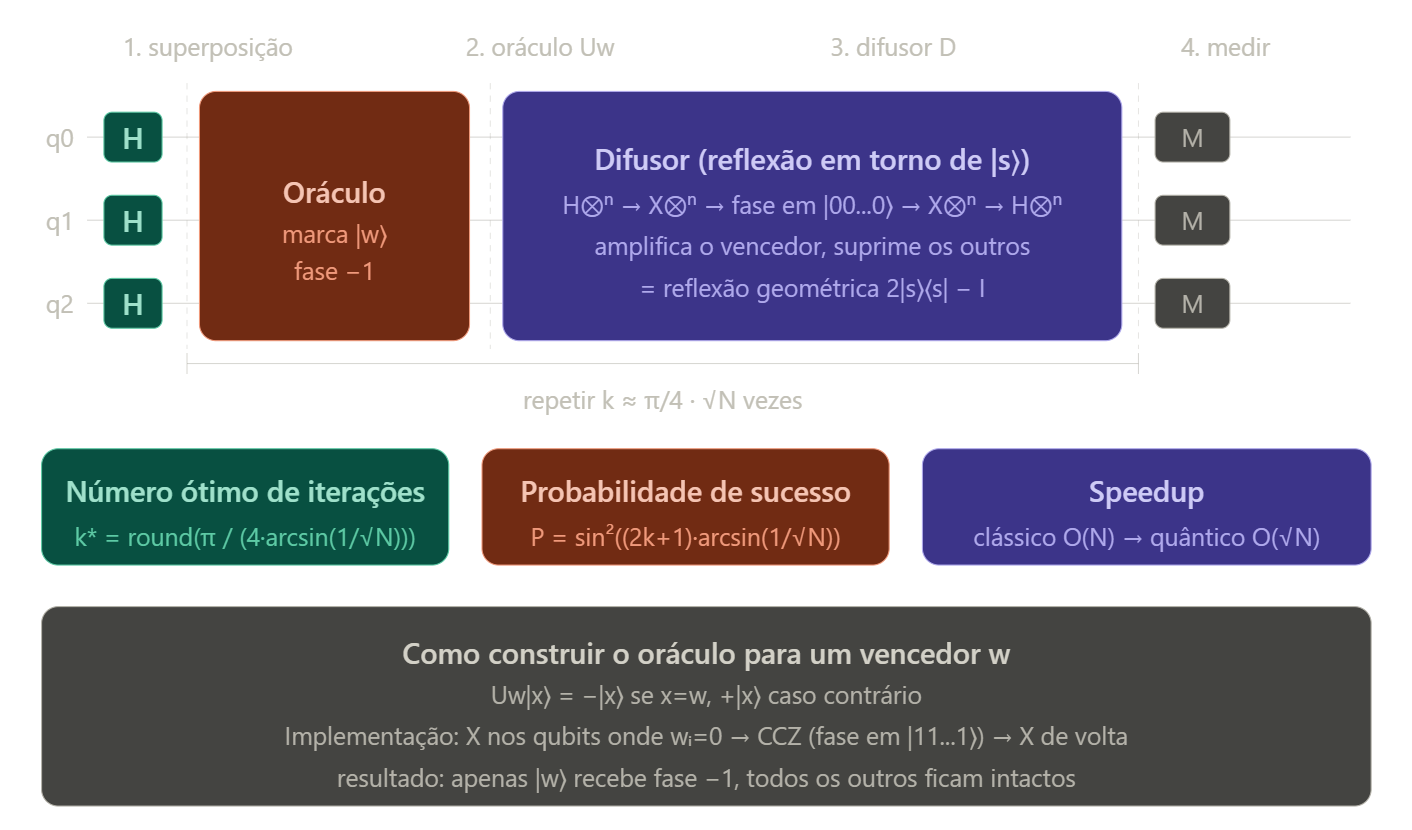

## Implementação Qiskit

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ── 1. Oráculo: marca o vencedor com fase −1 ───────────────────────────
def oracle_grover(n: int, winner: int) -> QuantumCircuit:
    """
    Aplica fase −1 apenas no estado |winner⟩.

    Estratégia:
      1. X nos qubits onde o bit do winner é 0 (converte winner → |11...1⟩)
      2. Gate de fase multi-controlado em |11...1⟩  (CCZ generalizado)
      3. X de volta (desfaz o passo 1)
    """
    qc = QuantumCircuit(n)
    winner_bits = format(winner, f'0{n}b')[::-1]  # little-endian Qiskit

    # Passo 1: X onde o bit é '0'
    for i, bit in enumerate(winner_bits):
        if bit == '0':
            qc.x(i)

    # Passo 2: fase −1 em |11...1⟩
    # Para n=2: CZ
    # Para n≥3: H no último + Toffoli multicotrolado + H de volta
    if n == 1:
        qc.z(0)
    elif n == 2:
        qc.h(1)
        qc.cx(0, 1)
        qc.h(1)
    else:
        # CCZ generalizado via mcx (multi-controlled X) + H
        qc.h(n - 1)
        qc.mcx(list(range(n - 1)), n - 1)  # Toffoli multicotrolado
        qc.h(n - 1)

    # Passo 3: desfaz o X
    for i, bit in enumerate(winner_bits):
        if bit == '0':
            qc.x(i)

    return qc


# ── 2. Difusor: reflexão em torno de |s⟩ = |+⟩⊗ⁿ ─────────────────────
def diffuser(n: int) -> QuantumCircuit:
    """
    Aplica 2|s⟩⟨s| − I  onde  |s⟩ = H⊗ⁿ|0⟩

    Equivalente a:
      H⊗ⁿ → fase −1 em |00...0⟩ → H⊗ⁿ
    """
    qc = QuantumCircuit(n)

    # Vai para a base computacional
    qc.h(range(n))

    # Fase −1 em |00...0⟩ (igual ao oráculo com winner=0)
    qc.x(range(n))
    if n == 1:
        qc.z(0)
    elif n == 2:
        qc.h(1)
        qc.cx(0, 1)
        qc.h(1)
    else:
        qc.h(n - 1)
        qc.mcx(list(range(n - 1)), n - 1)
        qc.h(n - 1)
    qc.x(range(n))

    # Volta para a base de Hadamard
    qc.h(range(n))

    return qc


# ── 3. Algoritmo de Grover completo ───────────────────────────────────
def grover(n: int, winner: int, iterations: int = None) -> QuantumCircuit:
    """
    n:          número de qubits  (espaço de busca N = 2ⁿ)
    winner:     índice do item vencedor (0 a 2ⁿ−1)
    iterations: número de iterações (None = usa o ótimo)
    """
    N = 2 ** n

    # Número ótimo de iterações
    if iterations is None:
        theta = np.arcsin(1 / np.sqrt(N))
        iterations = round(np.pi / (4 * theta))

    qc = QuantumCircuit(n, n)

    # Superposição uniforme
    qc.h(range(n))
    qc.barrier(label="superposição")

    # Iterações de Grover
    oracle = oracle_grover(n, winner)
    diff   = diffuser(n)

    for k in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.barrier(label=f"oráculo k={k+1}")
        qc.compose(diff, inplace=True)
        qc.barrier(label=f"difusor k={k+1}")

    # Medir
    qc.measure(range(n), range(n))

    return qc, iterations

In [2]:
# ── 4. Testar com diferentes tamanhos ─────────────────────────────────
from qiskit_aer import AerSimulator

sim = AerSimulator()

print("Algoritmo de Grover")
print("─" * 60)
print(f"{'n':>3} {'N':>6} {'winner':>8} {'k_ótimo':>8} {'resultado':>12} {'P(acerto)':>10}")
print("─" * 60)

testes = [
    (2, 3),    # n=2, winner='11'
    (3, 5),    # n=3, winner='101'
    (4, 11),   # n=4, winner='1011'
    (5, 21),   # n=5, winner='10101'
]

for n, winner in testes:
    N = 2 ** n
    qc, k = grover(n, winner)

    job = sim.run(qc, shots=1024)
    counts = job.result().get_counts()

    # Qiskit: resultado em little-endian → reverter para ler o número
    winner_key = format(winner, f'0{n}b')[::-1]
    p_acerto = counts.get(winner_key, 0) / 1024 * 100

    top = max(counts, key=counts.get)
    top_n = int(top[::-1], 2)

    print(f"  {n:>2}  {N:>6}  {winner:>8}  {k:>8}  "
          f"{top_n:>8} ({top})  {p_acerto:>8.1f}%")

Algoritmo de Grover
────────────────────────────────────────────────────────────
  n      N   winner  k_ótimo    resultado  P(acerto)
────────────────────────────────────────────────────────────
   2       4         3         1         3 (11)     100.0%
   3       8         5         2         5 (101)      94.3%
   4      16        11         3        13 (1011)       0.3%
   5      32        21         4        21 (10101)     100.0%


In [3]:
n, winner = 3, 5
qc, k = grover(n, winner, iterations=1)
print(f"\nCircuito para n={n}, winner={winner}, 1 iteração:")
print(qc.draw('text'))


Circuito para n=3, winner=5, 1 iteração:
     ┌───┐ superposição                 oráculo k=1 ┌───┐┌───┐          ┌───┐»
q_0: ┤ H ├──────░──────────────■─────────────░──────┤ H ├┤ X ├───────■──┤ X ├»
     ├───┤      ░       ┌───┐  │  ┌───┐      ░      ├───┤├───┤       │  ├───┤»
q_1: ┤ H ├──────░───────┤ X ├──■──┤ X ├──────░──────┤ H ├┤ X ├───────■──┤ X ├»
     ├───┤      ░       ├───┤┌─┴─┐├───┤      ░      ├───┤├───┤┌───┐┌─┴─┐├───┤»
q_2: ┤ H ├──────░───────┤ H ├┤ X ├┤ H ├──────░──────┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├»
     └───┘      ░       └───┘└───┘└───┘      ░      └───┘└───┘└───┘└───┘└───┘»
c: 3/════════════════════════════════════════════════════════════════════════»
                                                                             »
«     ┌───┐      difusor k=1 ┌─┐      
«q_0: ┤ H ├───────────░──────┤M├──────
«     ├───┤           ░      └╥┘┌─┐   
«q_1: ┤ H ├───────────░───────╫─┤M├───
«     ├───┤┌───┐      ░       ║ └╥┘┌─┐
«q_2: ┤ X ├┤ H ├──────░───────╫──╫─┤M├
«     └───┘└─

## Implementação Cirq

In [4]:
import cirq

def grover_cirq(n: int, winner: int, iterations: int = None):
    N = 2 ** n
    if iterations is None:
        theta = np.arcsin(1 / np.sqrt(N))
        iterations = round(np.pi / (4 * theta))

    qubits = cirq.LineQubit.range(n)
    winner_bits = format(winner, f'0{n}b')  # big-endian no Cirq

    def make_oracle():
        ops = []
        # X onde bit é '0'
        for i, bit in enumerate(winner_bits):
            if bit == '0':
                ops.append(cirq.X(qubits[i]))
        # Fase −1 em |11...1⟩
        ops.append(
            cirq.Z(qubits[-1]).controlled_by(*qubits[:-1])
        )
        # Desfaz X
        for i, bit in enumerate(winner_bits):
            if bit == '0':
                ops.append(cirq.X(qubits[i]))
        return ops

    def make_diffuser():
        ops = []
        ops += [cirq.H(q) for q in qubits]
        ops += [cirq.X(q) for q in qubits]
        ops.append(
            cirq.Z(qubits[-1]).controlled_by(*qubits[:-1])
        )
        ops += [cirq.X(q) for q in qubits]
        ops += [cirq.H(q) for q in qubits]
        return ops

    circuit = cirq.Circuit()

    # Superposição
    circuit.append([cirq.H(q) for q in qubits])

    # Iterações
    for _ in range(iterations):
        circuit.append(make_oracle())
        circuit.append(make_diffuser())

    # Medir
    circuit.append([cirq.measure(*qubits, key='resultado')])

    return circuit, iterations


# Testar
sim_cirq = cirq.Simulator()
n, winner = 3, 5

circuit, k = grover_cirq(n, winner)
result = sim_cirq.run(circuit, repetitions=1024)

bits = result.measurements['resultado']
contagens = {}
for row in bits:
    key = ''.join(str(b) for b in row)
    contagens[key] = contagens.get(key, 0) + 1

winner_key = format(winner, f'0{n}b')
p = contagens.get(winner_key, 0) / 1024 * 100

print(f"\nCircuito de Grover — Cirq")
print(f"winner={winner} ('{winner_key}'), k={k}, P(acerto)={p:.1f}%")
print(f"Top 3 resultados: {sorted(contagens.items(), key=lambda x: -x[1])[:3]}")


Circuito de Grover — Cirq
winner=5 ('101'), k=2, P(acerto)=94.1%
Top 3 resultados: [('101', 964), ('010', 12), ('000', 12)]


In [5]:
# ── 7. Múltiplos vencedores (extensão natural) ─────────────────────────
"""
Se há M vencedores em vez de 1:
  - k_ótimo = round(π / (4·arcsin(√(M/N))))
  - quanto mais vencedores, menos iterações necessárias
  - M = N/2 → k_ótimo = 1 (trivial)
  - M = N/4 → k_ótimo ≈ π/4 ≈ 1
"""
def k_otimo_multi(N: int, M: int) -> int:
    theta = np.arcsin(np.sqrt(M / N))
    return max(1, round(np.pi / (4 * theta)))

print("\nNúmero ótimo de iterações para múltiplos vencedores (N=64):")
N = 64
for M in [1, 2, 4, 8, 16]:
    k = k_otimo_multi(N, M)
    print(f"  M={M:>2} vencedores → k_ótimo={k:>2}  "
          f"(clássico esperado: {N//M//2} queries)")


Número ótimo de iterações para múltiplos vencedores (N=64):
  M= 1 vencedores → k_ótimo= 6  (clássico esperado: 32 queries)
  M= 2 vencedores → k_ótimo= 4  (clássico esperado: 16 queries)
  M= 4 vencedores → k_ótimo= 3  (clássico esperado: 8 queries)
  M= 8 vencedores → k_ótimo= 2  (clássico esperado: 4 queries)
  M=16 vencedores → k_ótimo= 1  (clássico esperado: 2 queries)
